In [1]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gseapy as gp
from adjustText import adjust_text


In [2]:

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=300, facecolor="white")
sc.set_figure_params(fontsize=6)
sc.settings.vector_friendly = False

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==2.0.2 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


# DGE and GSEA 

## Load Data and Prep

In [3]:
#Load annotataed file
adata_new = sc.read_h5ad("Final_Objects/PBMCs_anno_manual_refined_renamed.h5ad")
adata_new

AnnData object with n_obs × n_vars = 120853 × 1631
    obs: 'ExperimentID', 'ConditionID', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'Donor', 'Condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'predicted_doublet_0.2', 'predicted_doublet_0.25', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'Annotations_broad', 'Broad_Manual_Anno', 'Broad_Manual_Anno_renamed'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', '

In [4]:
adata_new = adata_new.raw.to_adata()

In [5]:
raw = sc.read_h5ad("Final_Objects/PBMC_raw.h5ad")

# Ensure alignment of cells and genes
# This assumes that obs (cells) and var (genes) match between the two objects
raw = raw[adata_new.obs_names, adata_new.var_names]

# Add raw counts into the .raw slot of adata_new
adata_new.raw = raw


In [6]:
# Set 'Condition' as an ordered categorical based on its current unique values
adata_new.obs['Condition'] = pd.Categorical(
    adata_new.obs['Condition'],
    categories=np.array(adata_new.obs['Condition'].unique()), 
    ordered=True
)

# Sort the data by both 'Broad_Manual_Anno_renamed' and 'Condition'
indices = adata_new.obs.sort_values(['Broad_Manual_Anno_renamed', 'Condition']).index

# Reorder the AnnData object based on the sorted indices
adata_new = adata_new[indices, :]


## Subset for conditions of interest to perform DGE and GO term analysis on CD4+ Treg Cells

In [7]:
bdata = adata_new[adata_new.obs.Broad_Manual_Anno_renamed == "CD4+ Treg Cells"].copy()
bdata = bdata[bdata.obs.Condition.isin(["Control","PHA + CM4620"])].copy()

In [8]:
bdata.layers['counts'] = bdata.raw.X

In [9]:
# --- CONFIG (edit these) ------------------------------------------------------
CONDITION_COLUMN = "Condition"        # bdata.obs column with conditions
SAMPLE_COLUMN    = "sample"           # bdata.obs column with sample IDs
BLOCK_COLUMN     = None               # e.g., "Donor" if you want paired design; else None

# Contrast: results will be (B vs A)
CONDITION_A = "Control"       # reference / denominator
CONDITION_B = "PHA + CM4620"  # numerator

# Filtering: keep genes with >= MIN_COUNT in at least MIN_SAMPLES pseudobulks
MIN_COUNT   = 10
MIN_SAMPLES = 2

# Output files (set to None to skip writing)
OUT_RAW_CSV   = "Final_Objects/DESeq_psudobulk/CM4620_deseq2_results_raw.csv"
OUT_SHR_CSV   = "Final_Objects/DESeq_psudobulk/CM4620_deseq2_results_shrunk.csv"
OUT_NORM_CSV  = "Final_Objects/DESeq_psudobulk/CM4620_deseq2_normalized_counts.csv"

# ----------------------------

import scipy.sparse as sp
import decoupler as dc

# 1) Build pseudobulk (sum UMI counts per gene within each sample)
# Prefer counts layer if present:
layer_name = "counts" if "counts" in bdata.layers else None

pb = dc.get_pseudobulk(
    bdata,
    sample_col=SAMPLE_COLUMN,
    groups_col=[CONDITION_COLUMN],   # keeps Condition in pb.obs
    layer=layer_name,                # None => uses .X
    mode="sum",
    min_cells=0,
    min_counts=0,
)

# Ensure integer counts (PyDESeq2 expects integers)
if sp.issparse(pb.X):
    pb.X = pb.X.A
pb.X = np.asarray(np.rint(pb.X), dtype=np.int64)

# 2) Basic gene filtering (fast, bulk-style)
# Keep genes with >= MIN_COUNT in >= MIN_SAMPLES samples overall
keep = (pb.X >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
pb = pb[:, np.where(keep)[0]].copy()

# 3) Make sure we have exactly two condition levels and >=2 reps per level
conds = pb.obs[CONDITION_COLUMN].astype(str)
levels = pd.Index(sorted(conds.unique()))
if len(levels) != 2:
    raise ValueError(f"Expected exactly 2 condition levels in '{CONDITION_COLUMN}', found {list(levels)}.")
counts_per_level = conds.value_counts()
if (counts_per_level < 2).any():
    raise ValueError(f"Each condition needs >=2 replicates for DESeq2 pseudobulk. Got:\n{counts_per_level}")

REF = CONDITION_A         # reference level (denominator)
TEST = CONDITION_B    # tested level (numerator)

# 4) (Optional) Include a blocking factor if you have one (e.g., Donor)
design_factors = [CONDITION_COLUMN]
if BLOCK_COLUMN is not None:
    if BLOCK_COLUMN not in pb.obs.columns:
        raise ValueError(f"Missing '{BLOCK_COLUMN}' in pb.obs")
    design_factors = [BLOCK_COLUMN, CONDITION_COLUMN]

# 5) Run DE with PyDESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    adata=pb,                         # uses pb.X as counts, pb.obs as metadata
    design_factors=design_factors,    # e.g., ["Condition"] or ["Donor","Condition"]
    ref_level=[CONDITION_COLUMN, REF],
    refit_cooks=True,
    inference=inference,
)

# Fit (size factors, dispersions, GLMs)
dds.deseq2()

# Results for TEST vs REF
stat_res = DeseqStats(
    dds,
    contrast=[CONDITION_COLUMN, TEST, REF],
    inference=inference,
)
stat_res.summary()  # computes Wald stats (log2FC, pvalue, padj)

# 1) RAW (pre-shrink) results
res_raw = stat_res.results_df.copy()

# 2) LFC shrinkage; this updates stat_res.results_df IN PLACE
coeff_name = stat_res.LFC.columns[stat_res.contrast_idx]
stat_res.lfc_shrink(coeff=coeff_name)

# 3) SHRUNK results (now 'log2FoldChange' is the shrunken one)
res_shr = stat_res.results_df.copy()

# ---- NEW: keep gene names explicitly in a column ----
# PyDESeq2 uses gene names as the index. Add them as a column for easy CSV usage.
res_raw = res_raw.copy()
res_raw.insert(0, "gene", res_raw.index.astype(str))

res_shr = res_shr.copy()
res_shr.insert(0, "gene", res_shr.index.astype(str))

# (Optional) If your pseudobulk has additional gene metadata (e.g., gene_symbol),
# append those too so you keep both ID and symbol.
for extra_col in ["gene_symbol", "gene_id", "feature_name"]:
    if extra_col in pb.var.columns:
        mapper = pb.var[extra_col].astype(str)
        mapper.index = pb.var_names.astype(str)
        res_raw[extra_col] = res_raw["gene"].map(mapper)
        res_shr[extra_col] = res_shr["gene"].map(mapper)

# ---- keep numeric dtypes robustly ----
for col in ["log2FoldChange", "padj", "pvalue", "baseMean", "lfcSE", "stat"]:
    if col in res_shr.columns:
        res_shr[col] = pd.to_numeric(res_shr[col], errors="coerce")
    if col in res_raw.columns:
        res_raw[col] = pd.to_numeric(res_raw[col], errors="coerce")

# ---- NEW: export normalized counts with gene names ----
if OUT_NORM_CSV:
    # PyDESeq2 API differs slightly by version; try both.
    try:
        norm_counts = dds.norm_counts()  # samples x genes (DataFrame)
    except AttributeError:
        try:
            norm_counts = dds.get_normalized_counts()  # older versions
        except AttributeError:
            # Fallback: if exposed as a layer or ndarray (rare)
            # This may not exist depending on version; provided as a last resort.
            norm_arr = dds.layers.get("normed_counts", None) if hasattr(dds, "layers") else None
            if norm_arr is None:
                raise RuntimeError("Could not retrieve normalized counts from DESeq2 object.")
            norm_counts = pd.DataFrame(norm_arr, index=dds.obs_names, columns=dds.var_names)

    # Write as gene x sample with a 'gene' column first
    norm_counts_T = norm_counts.T  # genes x samples
    norm_counts_T.insert(0, "gene", norm_counts_T.index.astype(str))
    norm_counts_T.to_csv(OUT_NORM_CSV, index=False)

# Save DE results (optional)
if OUT_RAW_CSV:
    res_raw.to_csv(OUT_RAW_CSV, index=False)
if OUT_SHR_CSV:
    res_shr.to_csv(OUT_SHR_CSV, index=False)

# Sanity check
print("Top DE genes (shrunken LFC):")
print(
    res_shr
    .sort_values("padj")
    .loc[:, [c for c in ["gene", "gene_symbol", "log2FoldChange", "padj", "baseMean"] if c in res_shr.columns]]
    .head(10)
)


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 0.99 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 1.05 seconds.

Fitting LFCs...
... done in 1.06 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.55 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: Condition PHA + CM4620 vs Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG    11.148306       -0.987572  0.474490 -2.081333  0.037403  0.133150
AAGAB    8.585013        0.277051  0.489764  0.565683  0.571609  0.756996
AAK1    71.432021       -0.974210  0.211141 -4.614023  0.000004  0.000080
AAMP    14.625745        0.295746  0.387815  0.762597  0.445704  0.662352
AARS    11.306838        1.600135  0.488114  3.278201  0.001045  0.008891
...           ...             ...       ...       ...       ...       ...
ZSWIM8   7.363180       -1.036399  0.574696 -1.803385  0.071328  0.207688
ZXDC     5.540129       -1.293309  0.651209 -1.986012  0.047032  0.156632
ZYG11B   7.728935       -0.809466  0.522455 -1.549351  0.121297  0.294902
ZYX     22.482850        1.034750  0.339652  3.046496  0.002315  0.016955
ZZEF1   10.235412       -0.704165  0.473230 -1.487999  0.136751  0.319086

[6667 rows x 6 columns]


... done in 1.32 seconds.



Shrunk log2 fold change & Wald test p-value: Condition PHA + CM4620 vs Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG    11.148306       -0.630656  0.473941 -2.081333  0.037403  0.133150
AAGAB    8.585013        0.129043  0.401501  0.565683  0.571609  0.756996
AAK1    71.432021       -0.907136  0.212516 -4.614023  0.000004  0.000080
AAMP    14.625745        0.175627  0.342013  0.762597  0.445704  0.662352
AARS    11.306838        1.303455  0.501608  3.278201  0.001045  0.008891
...           ...             ...       ...       ...       ...       ...
ZSWIM8   7.363180       -0.531289  0.542789 -1.803385  0.071328  0.207688
ZXDC     5.540129       -0.631801  0.639407 -1.986012  0.047032  0.156632
ZYG11B   7.728935       -0.415763  0.471892 -1.549351  0.121297  0.294902
ZYX     22.482850        0.859614  0.346012  3.046496  0.002315  0.016955
ZZEF1   10.235412       -0.390398  0.429929 -1.487999  0.136751  0.319086

[6667 rows x 6 columns]
Top DE g

In [282]:
res_shr['gene'] = res_shr.index

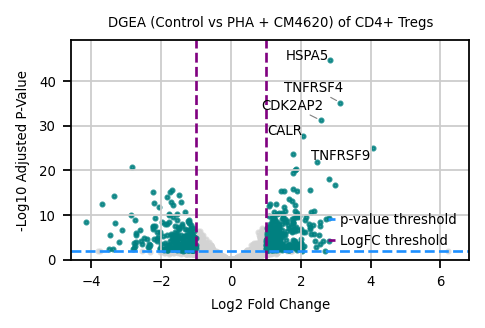

In [283]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()

# Plot labels
plot_title = "DGEA (Control vs PHA + CM4620) of CD4+ Tregs"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(3, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(row["LogFC"], row["-Log10P"], row["Gene"],
                 fontsize=6, ha="right", va="bottom", color="black")
    )

# Nudge labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="lower right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.1 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()


In [284]:
import numpy as np
import pandas as pd

# --- Inputs: DESeq2/PyDESeq2 shrunk results ---
# res_shr_df must have: 'gene', 'log2FoldChange', 'padj'
df = res_shr.copy()

# Thresholds (same as your volcano)
fc_threshold   = 1.0
pval_threshold = 0.01

# Clean + prepare
df = df.rename(columns={'gene':'Gene', 'log2FoldChange':'LogFC', 'padj':'Adjusted_PValue'})
df['LogFC'] = pd.to_numeric(df['LogFC'], errors='coerce')
df['Adjusted_PValue'] = pd.to_numeric(df['Adjusted_PValue'], errors='coerce')
df = df.dropna(subset=['LogFC','Adjusted_PValue'])

# For sorting by significance like your volcano (-log10 padj)
df['-Log10P'] = -np.log10(df['Adjusted_PValue'].clip(lower=1e-300))

# Regulation labels
df['Regulation'] = np.where(
    df['LogFC'] >  fc_threshold, 'Upregulated',
    np.where(df['LogFC'] < -fc_threshold, 'Downregulated', 'Non-significant')
)

# Significant mask (|LFC| & padj)
significant = (df['Adjusted_PValue'] < pval_threshold) & (df['LogFC'].abs() > fc_threshold)

# Sort: most significant first, then by effect size
significant_genes_df = (
    df.loc[significant]
      .assign(absLFC=lambda x: x['LogFC'].abs())
      .sort_values(by=['-Log10P','absLFC'], ascending=[False, False])
      .drop(columns=['absLFC'])
)

# Save
# filename = 'Final_Notebooks/Figures/Drug_DGE/significant_genes_Control_vs_PHA_CM4620_CD4Treg.csv'
# cols_out = ['Gene','LogFC','Adjusted_PValue','Regulation']
# significant_genes_df[cols_out].to_csv(filename, index=False)

# print(f"Saved {significant_genes_df.shape[0]} significant genes -> {filename}")


In [285]:
Up_genes = significant_genes_df[significant_genes_df.Regulation=='Upregulated'].Gene
Down_genes = significant_genes_df[significant_genes_df.Regulation=='Downregulated'].Gene

In [286]:
# Run Enrichr on upregulated DEGs using a local GMT file
enr_up = gp.enrichr(
    gene_list=Up_genes,
    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
    organism='human',
    outdir=None
)

# Clean up term names (remove prefix) and filter for specific immune terms
enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(
    lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None
)
enr_up.res2d = enr_up.res2d[
    (enr_up.res2d["Adjusted P-value"] < 0.05) &
    (enr_up.res2d['Term'].str.contains(r'TOLERANCE|REGULATION_OF_T_|CYTOTOX', na=False))
]

# Sort by significance
enr_up.res2d = enr_up.res2d.sort_values('Adjusted P-value', ascending=True)

enr_up.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2696,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_T_CELL_ACTIVATION,20/381,4.015667e-07,0.000051,4.266468,62.836087,ACTB;IRF4;PNP;CD40LG;HSPH1;HSPD1;LGALS1;SIRPG;...


In [300]:
np.array(enr_up.res2d['Genes'][0:1])

array(['ACTB;IRF4;PNP;CD40LG;HSPH1;HSPD1;LGALS1;SIRPG;DUSP10;BATF;SELENOK;PTPN6;CTLA4;IL4I1;YES1;TNFRSF9;LRRC32;TFRC;XBP1;CORO1A'],
      dtype=object)

In [199]:
# Run Enrichr on downregulated DEGs using local GMT file
enr_dw = gp.enrichr(
    gene_list=Down_genes,
    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
    organism='human',
    outdir=None
)

# Clean up term names (remove GO category prefix like GO_REGULATION_OF_...)
enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(
    lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None
)

# Filter by significance
enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"] < 0.05]

# Keep only terms related to tolerance, T cell regulation, or cytotoxicity
enr_dw.res2d = enr_dw.res2d[
    enr_dw.res2d['Term'].str.contains(r'TOLERANCE|REGULATION_OF_T_|CYTOTOX', na=False)
]

enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1831,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_PROLIFERATION,6/105,0.000560,0.028587,6.831528,51.149178,SPN;HLA-DPB1;TNFRSF13C;HLA-DPA1;ANXA1;CD55
2500,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_T_CELL_ACTIVATION,13/381,0.000093,0.009397,3.927210,36.446613,TCF7;RIPOR2;LEF1;SPN;FYN;HLA-DPB1;TNFRSF13C;CA...


In [200]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(9), enr_dw.res2d.head()])

/tmp/ipykernel_981355/3684754672.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


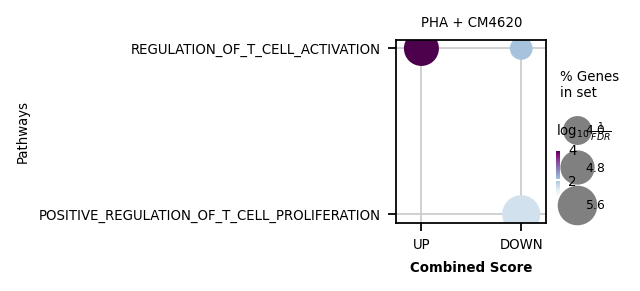

In [202]:
# Define order of key T cell regulatory pathways
order = [
    'POSITIVE_REGULATION_OF_T_CELL_PROLIFERATION',
    'REGULATION_OF_T_CELL_ACTIVATION'
]

# Generate dotplot with gseapy
ax = gp.dotplot(
    enr_res,
    figsize=(1.5, 1.5),
    x='UP_DW',                    # Column with UP/DOWN label
    x_order=["UP", "DOWN"],
    title="GO_BP",
    cmap='BuPu',
    size=50,
    y_order=order,
    show_ring=False
)

# Customize axes and labels
ax.set_title("PHA + CM4620", fontsize=6)
ax.set_xlabel("Combined Score", fontsize=6)
ax.set_ylabel("Pathways", fontsize=6)
ax.tick_params(axis='both', which='major', labelsize=6)

# Save and show plot
plt.tight_layout()
plt.savefig('Figures/Drug_DGE/GSEA_DESeq2_CM4620.pdf', bbox_inches='tight', dpi=300)
plt.show()


## For stimulated BTP2 treated cells vs Control

In [10]:
bdata = adata_new[adata_new.obs.Broad_Manual_Anno_renamed == "CD4+ Treg Cells"].copy()
bdata = bdata[bdata.obs.Condition.isin(["Control","PHA + BTP2"])].copy()
bdata

AnnData object with n_obs × n_vars = 957 × 16537
    obs: 'ExperimentID', 'ConditionID', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'Donor', 'Condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'predicted_doublet_0.2', 'predicted_doublet_0.25', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'Annotations_broad', 'Broad_Manual_Anno', 'Broad_Manual_Anno_renamed'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'hi

In [11]:
bdata.layers['counts'] = bdata.raw.X

In [12]:
# --- CONFIG (edit these) ------------------------------------------------------
CONDITION_COLUMN = "Condition"        # bdata.obs column with conditions
SAMPLE_COLUMN    = "sample"           # bdata.obs column with sample IDs
BLOCK_COLUMN     = None               # e.g., "Donor" if you want paired design; else None

# Contrast: results will be (B vs A)
CONDITION_A = "Control"       # reference / denominator
CONDITION_B = "PHA + BTP2"  # numerator

# Filtering: keep genes with >= MIN_COUNT in at least MIN_SAMPLES pseudobulks
MIN_COUNT   = 10
MIN_SAMPLES = 2

# Output files (set to None to skip writing)
OUT_RAW_CSV   = "Final_Objects/DESeq_psudobulk/BTP2_deseq2_results_raw.csv"
OUT_SHR_CSV   = "Final_Objects/DESeq_psudobulk/BTP2_deseq2_results_shrunk.csv"

# ----------------------------

import scipy.sparse as sp
import decoupler as dc

# 1) Build pseudobulk (sum UMI counts per gene within each sample)
# Prefer counts layer if present:
layer_name = "counts" if "counts" in bdata.layers else None

pb = dc.get_pseudobulk(
    bdata,
    sample_col=SAMPLE_COLUMN,
    groups_col=[CONDITION_COLUMN],   # keeps Condition in pb.obs
    layer=layer_name,                # None => uses .X
    mode="sum",
    min_cells=0,
    min_counts=0,
)

# Ensure integer counts (PyDESeq2 expects integers)
if sp.issparse(pb.X):
    pb.X = pb.X.A
pb.X = np.asarray(np.rint(pb.X), dtype=np.int64)

# 2) Basic gene filtering (fast, bulk-style)
# Keep genes with >= MIN_COUNT in >= MIN_SAMPLES samples overall
keep = (pb.X >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
pb = pb[:, np.where(keep)[0]].copy()

# 3) Make sure we have exactly two condition levels and >=2 reps per level
conds = pb.obs[CONDITION_COLUMN].astype(str)
levels = pd.Index(sorted(conds.unique()))
if len(levels) != 2:
    raise ValueError(f"Expected exactly 2 condition levels in '{CONDITION_COLUMN}', found {list(levels)}.")
counts_per_level = conds.value_counts()
if (counts_per_level < 2).any():
    raise ValueError(f"Each condition needs >=2 replicates for DESeq2 pseudobulk. Got:\n{counts_per_level}")

REF = CONDITION_A         # reference level (denominator)
TEST = CONDITION_B    # tested level (numerator)

# 4) (Optional) Include a blocking factor if you have one (e.g., Donor)
design_factors = [CONDITION_COLUMN]
if BLOCK_COLUMN is not None:
    if BLOCK_COLUMN not in pb.obs.columns:
        raise ValueError(f"Missing '{BLOCK_COLUMN}' in pb.obs")
    design_factors = [BLOCK_COLUMN, CONDITION_COLUMN]

# 5) Run DE with PyDESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    adata=pb,                         # uses pb.X as counts, pb.obs as metadata
    design_factors=design_factors,    # e.g., ["Condition"] or ["Donor","Condition"]
    ref_level=[CONDITION_COLUMN, REF],
    refit_cooks=True,
    inference=inference,
)

# Fit (size factors, dispersions, GLMs)
dds.deseq2()

# Results for TEST vs REF
stat_res = DeseqStats(
    dds,
    contrast=[CONDITION_COLUMN, TEST, REF],
    inference=inference,
)
stat_res.summary()  # computes Wald stats (log2FC, pvalue, padj)

# 1) RAW (pre-shrink) results
res_raw = stat_res.results_df.copy()

# 2) LFC shrinkage; this updates stat_res.results_df IN PLACE
coeff_name = stat_res.LFC.columns[stat_res.contrast_idx]
stat_res.lfc_shrink(coeff=coeff_name)

# 3) SHRUNK results (now 'log2FoldChange' is the shrunken one)
res_shr = stat_res.results_df.copy()

# ---- NEW: keep gene names explicitly in a column ----
# PyDESeq2 uses gene names as the index. Add them as a column for easy CSV usage.
res_raw = res_raw.copy()
res_raw.insert(0, "gene", res_raw.index.astype(str))

res_shr = res_shr.copy()
res_shr.insert(0, "gene", res_shr.index.astype(str))

# (Optional) If your pseudobulk has additional gene metadata (e.g., gene_symbol),
# append those too so you keep both ID and symbol.
for extra_col in ["gene_symbol", "gene_id", "feature_name"]:
    if extra_col in pb.var.columns:
        mapper = pb.var[extra_col].astype(str)
        mapper.index = pb.var_names.astype(str)
        res_raw[extra_col] = res_raw["gene"].map(mapper)
        res_shr[extra_col] = res_shr["gene"].map(mapper)

# ---- keep numeric dtypes robustly ----
for col in ["log2FoldChange", "padj", "pvalue", "baseMean", "lfcSE", "stat"]:
    if col in res_shr.columns:
        res_shr[col] = pd.to_numeric(res_shr[col], errors="coerce")
    if col in res_raw.columns:
        res_raw[col] = pd.to_numeric(res_raw[col], errors="coerce")

# ---- NEW: export normalized counts with gene names ----
if OUT_NORM_CSV:
    # PyDESeq2 API differs slightly by version; try both.
    try:
        norm_counts = dds.norm_counts()  # samples x genes (DataFrame)
    except AttributeError:
        try:
            norm_counts = dds.get_normalized_counts()  # older versions
        except AttributeError:
            # Fallback: if exposed as a layer or ndarray (rare)
            # This may not exist depending on version; provided as a last resort.
            norm_arr = dds.layers.get("normed_counts", None) if hasattr(dds, "layers") else None
            if norm_arr is None:
                raise RuntimeError("Could not retrieve normalized counts from DESeq2 object.")
            norm_counts = pd.DataFrame(norm_arr, index=dds.obs_names, columns=dds.var_names)

    # Write as gene x sample with a 'gene' column first
    norm_counts_T = norm_counts.T  # genes x samples
    norm_counts_T.insert(0, "gene", norm_counts_T.index.astype(str))
    norm_counts_T.to_csv(OUT_NORM_CSV, index=False)

# Save DE results (optional)
if OUT_RAW_CSV:
    res_raw.to_csv(OUT_RAW_CSV, index=False)
if OUT_SHR_CSV:
    res_shr.to_csv(OUT_SHR_CSV, index=False)

# Sanity check
print("Top DE genes (shrunken LFC):")
print(
    res_shr
    .sort_values("padj")
    .loc[:, [c for c in ["gene", "gene_symbol", "log2FoldChange", "padj", "baseMean"] if c in res_shr.columns]]
    .head(10)
)




Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.02 seconds.

Fitting dispersion trend curve...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 1.13 seconds.

Fitting LFCs...
... done in 1.26 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.58 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: Condition PHA + BTP2 vs Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG     9.979650       -0.596091  0.506758 -1.176282  0.239482  0.483031
AAGAB    7.944347        0.560805  0.500755  1.119918  0.262748  0.508353
AAK1    60.234267       -0.963149  0.222950 -4.320025  0.000016  0.000309
AAMP    16.037934        0.840821  0.375128  2.241424  0.024999  0.111410
AARS     8.787989        1.409283  0.506454  2.782647  0.005392  0.035949
...           ...             ...       ...       ...       ...       ...
ZSWIM8   6.035766       -1.095456  0.605187 -1.810113  0.070278  0.225157
ZXDC     5.161868       -0.658208  0.606027 -1.086104  0.277433  0.525378
ZYG11B   6.582717       -0.756672  0.558125 -1.355738  0.175182  0.400578
ZYX     18.079973        0.872093  0.376029  2.319220  0.020383  0.096556
ZZEF1    8.929953       -0.620166  0.481390 -1.288282  0.197648  0.432814

[6416 rows x 6 columns]


... done in 1.15 seconds.



Shrunk log2 fold change & Wald test p-value: Condition PHA + BTP2 vs Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG     9.979650       -0.276749  0.420473 -1.176282  0.239482  0.483031
AAGAB    7.944347        0.258447  0.425376  1.119918  0.262748  0.508353
AAK1    60.234267       -0.886120  0.224528 -4.320025  0.000016  0.000309
AAMP    16.037934        0.605687  0.377424  2.241424  0.024999  0.111410
AARS     8.787989        1.036078  0.528482  2.782647  0.005392  0.035949
...           ...             ...       ...       ...       ...       ...
ZSWIM8   6.035766       -0.513170  0.559368 -1.810113  0.070278  0.225157
ZXDC     5.161868       -0.245292  0.451982 -1.086104  0.277433  0.525378
ZYG11B   6.582717       -0.327537  0.461501 -1.355738  0.175182  0.400578
ZYX     18.079973        0.633347  0.382027  2.319220  0.020383  0.096556
ZZEF1    8.929953       -0.308663  0.411629 -1.288282  0.197648  0.432814

[6416 rows x 6 columns]
Top DE gen

In [13]:
res_shr['gene'] = res_shr.index

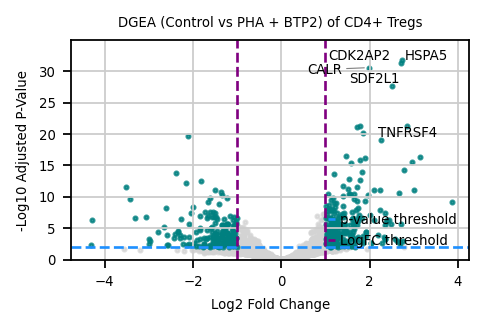

In [15]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()

# Plot labels
plot_title = "DGEA (Control vs PHA + BTP2) of CD4+ Tregs"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(3, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(row["LogFC"], row["-Log10P"], row["Gene"],
                 fontsize=6, ha="right", va="bottom", color="black")
    )

# Nudge labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="lower right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.1 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()


In [306]:
import numpy as np
import pandas as pd

# --- Inputs: DESeq2/PyDESeq2 shrunk results ---
# res_shr_df must have: 'gene', 'log2FoldChange', 'padj'
df = res_shr.copy()

# Thresholds (same as your volcano)
fc_threshold   = 1.0
pval_threshold = 0.01

# Clean + prepare
df = df.rename(columns={'gene':'Gene', 'log2FoldChange':'LogFC', 'padj':'Adjusted_PValue'})
df['LogFC'] = pd.to_numeric(df['LogFC'], errors='coerce')
df['Adjusted_PValue'] = pd.to_numeric(df['Adjusted_PValue'], errors='coerce')
df = df.dropna(subset=['LogFC','Adjusted_PValue'])

# For sorting by significance like your volcano (-log10 padj)
df['-Log10P'] = -np.log10(df['Adjusted_PValue'].clip(lower=1e-300))

# Regulation labels
df['Regulation'] = np.where(
    df['LogFC'] >  fc_threshold, 'Upregulated',
    np.where(df['LogFC'] < -fc_threshold, 'Downregulated', 'Non-significant')
)

# Significant mask (|LFC| & padj)
significant = (df['Adjusted_PValue'] < pval_threshold) & (df['LogFC'].abs() > fc_threshold)

# Sort: most significant first, then by effect size
significant_genes_df = (
    df.loc[significant]
      .assign(absLFC=lambda x: x['LogFC'].abs())
      .sort_values(by=['-Log10P','absLFC'], ascending=[False, False])
      .drop(columns=['absLFC'])
)

# Save
# filename = 'Final_Notebooks/Figures/Drug_DGE/significant_genes_Control_vs_PHA_BTP2_CD4Treg.csv'
# cols_out = ['Gene','LogFC','Adjusted_PValue','Regulation']
# significant_genes_df[cols_out].to_csv(filename, index=False)

# print(f"Saved {significant_genes_df.shape[0]} significant genes -> {filename}")


In [307]:
Up_genes = significant_genes_df[significant_genes_df.Regulation=='Upregulated'].Gene
Down_genes = significant_genes_df[significant_genes_df.Regulation=='Downregulated'].Gene

In [308]:
# Run Enrichr on upregulated genes
enr_up = gp.enrichr(
    gene_list=Up_genes,
    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
    organism='human',
    outdir=None
)

# Clean up term names and filter for relevant immune-related categories
enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(
    lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else x
)
enr_up.res2d = enr_up.res2d[
    (enr_up.res2d["Adjusted P-value"] < 0.05) &
    (enr_up.res2d['Term'].str.contains(r'TOLERANCE|REGULATION_OF_T_|CYTOTOX', na=False))
]

# Sort by significance
enr_up.res2d = enr_up.res2d.sort_values('Adjusted P-value')

enr_up.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2621,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_T_CELL_ACTIVATION,21/381,9.383388e-09,0.000002,5.201023,96.137401,ACTB;IRF4;PNP;CD40LG;HSPH1;HSPD1;IL23A;RAC2;LG...
826,c5.all.v2023.2.Hs.symbols.gmt,LEUKOCYTE_MEDIATED_CYTOTOXICITY,7/139,1.584559e-03,0.032013,4.692465,30.254430,PTPN6;PRDX1;CEBPG;TUBB;TUBB4B;IL23A;CORO1A
1917,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_PROLIFERATION,6/105,1.799613e-03,0.034627,5.401511,34.138541,SELENOK;PNP;CD40LG;SLC7A1;IL23A;CORO1A


In [309]:
np.array(enr_up.res2d['Genes'][0:1])

array(['ACTB;IRF4;PNP;CD40LG;HSPH1;HSPD1;IL23A;RAC2;LGALS1;SIRPG;BATF;SLC7A1;SELENOK;PTPN6;CTLA4;IL4I1;YES1;TNFRSF9;LRRC32;XBP1;CORO1A'],
      dtype=object)

In [211]:
# Run Enrichr on downregulated genes from "PHA + BTP2"
enr_dw = gp.enrichr(
    gene_list=Down_genes,
    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
    organism='human',
    outdir=None
)

# Remove GO term prefixes (e.g., GO_REGULATION_OF_T_CELL...)
enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(
    lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None
)

# Filter for significant pathways
enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"] < 0.05]

# Keep only immune regulation / cytotoxicity / tolerance related terms
enr_dw.res2d = enr_dw.res2d[
    enr_dw.res2d['Term'].str.contains(r'TOLERANCE_|REGULATION_OF_T_|CYTOTOX', na=False)
]

enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2131,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_T_CELL_ACTIVATION,12/381,0.000031,0.004496,4.769456,49.528983,RIPOR2;LEF1;SPN;FYN;HLA-DPB1;SMAD7;CAMK4;RASGR...
2133,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_T_CELL_DIFFERENTIATION_IN_THYMUS,3/27,0.001058,0.044339,19.221005,131.695511,CAMK4;RASGRP1;IL7R


In [212]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(9), enr_dw.res2d.head()])

/tmp/ipykernel_981355/3589197600.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


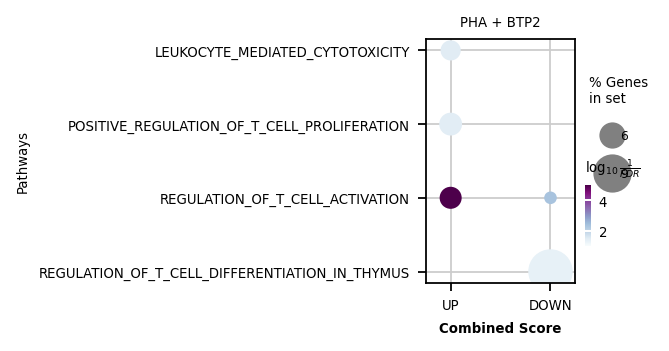

In [216]:
# Plot GO enrichment dotplot for PHA + BTP2 (UP vs DOWN regulated)
ax = gp.dotplot(
    enr_res,                      # DataFrame with enrichment results and 'UP_DW' column
    figsize=(1.5, 2),
    x='UP_DW',                    # Column defining Up vs Down regulation
    x_order=["UP", "DOWN"],       # Ensure fixed column order
    title="GO_BP",
    cmap='BuPu',                  # Purple-to-blue color scale
    size=30,
    show_ring=False,              # No donut rings
    vmin=0                        # Lower bound of color scale
)

# Customize axis titles
ax.set_title("PHA + BTP2", fontsize=6)
ax.set_xlabel("Combined Score", fontsize=6)
ax.set_ylabel("Pathways", fontsize=6)

# Adjust tick size
ax.tick_params(axis='both', which='major', labelsize=6)

# Layout and save
plt.tight_layout()
plt.savefig('Figures/Drug_DGE/GSEA_DESeq2_BTP2.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Cytotoxicity in PHA vs Control in CD8+ Effector T cells

In [18]:
bdata = adata_new[adata_new.obs.Broad_Manual_Anno_renamed.isin(["CD8+ Effector T Cells"])].copy()
bdata = bdata[bdata.obs.Condition.isin(["Control","PHA"])].copy()
bdata

AnnData object with n_obs × n_vars = 5207 × 16537
    obs: 'ExperimentID', 'ConditionID', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'Donor', 'Condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'predicted_doublet_0.2', 'predicted_doublet_0.25', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'Annotations_broad', 'Broad_Manual_Anno', 'Broad_Manual_Anno_renamed'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'h

In [19]:
bdata.layers['counts'] = bdata.raw.X

In [20]:
# --- CONFIG (edit these) ------------------------------------------------------
CONDITION_COLUMN = "Condition"        # bdata.obs column with conditions
SAMPLE_COLUMN    = "sample"           # bdata.obs column with sample IDs
BLOCK_COLUMN     = None               # e.g., "Donor" if you want paired design; else None

# Contrast: results will be (B vs A)
CONDITION_A = "Control"       # reference / denominator
CONDITION_B = "PHA"  # numerator

# Filtering: keep genes with >= MIN_COUNT in at least MIN_SAMPLES pseudobulks
MIN_COUNT   = 10
MIN_SAMPLES = 2

# Output files (set to None to skip writing)
OUT_RAW_CSV   = "Final_Objects/DESeq_psudobulk/PHA_CD8_deseq2_results_raw.csv"
OUT_SHR_CSV   = "Final_Objects/DESeq_psudobulk/PHA_CD8_deseq2_results_shrunk.csv"

# ----------------------------

import scipy.sparse as sp
import decoupler as dc

# 1) Build pseudobulk (sum UMI counts per gene within each sample)
# Prefer counts layer if present:
layer_name = "counts" if "counts" in bdata.layers else None

pb = dc.get_pseudobulk(
    bdata,
    sample_col=SAMPLE_COLUMN,
    groups_col=[CONDITION_COLUMN],   # keeps Condition in pb.obs
    layer=layer_name,                # None => uses .X
    mode="sum",
    min_cells=0,
    min_counts=0,
)

# Ensure integer counts (PyDESeq2 expects integers)
if sp.issparse(pb.X):
    pb.X = pb.X.A
pb.X = np.asarray(np.rint(pb.X), dtype=np.int64)

# 2) Basic gene filtering (fast, bulk-style)
# Keep genes with >= MIN_COUNT in >= MIN_SAMPLES samples overall
keep = (pb.X >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
pb = pb[:, np.where(keep)[0]].copy()

# 3) Make sure we have exactly two condition levels and >=2 reps per level
conds = pb.obs[CONDITION_COLUMN].astype(str)
levels = pd.Index(sorted(conds.unique()))
if len(levels) != 2:
    raise ValueError(f"Expected exactly 2 condition levels in '{CONDITION_COLUMN}', found {list(levels)}.")
counts_per_level = conds.value_counts()
if (counts_per_level < 2).any():
    raise ValueError(f"Each condition needs >=2 replicates for DESeq2 pseudobulk. Got:\n{counts_per_level}")

REF = CONDITION_A         # reference level (denominator)
TEST = CONDITION_B    # tested level (numerator)

# 4) (Optional) Include a blocking factor if you have one (e.g., Donor)
design_factors = [CONDITION_COLUMN]
if BLOCK_COLUMN is not None:
    if BLOCK_COLUMN not in pb.obs.columns:
        raise ValueError(f"Missing '{BLOCK_COLUMN}' in pb.obs")
    design_factors = [BLOCK_COLUMN, CONDITION_COLUMN]

# 5) Run DE with PyDESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    adata=pb,                         # uses pb.X as counts, pb.obs as metadata
    design_factors=design_factors,    # e.g., ["Condition"] or ["Donor","Condition"]
    ref_level=[CONDITION_COLUMN, REF],
    refit_cooks=True,
    inference=inference,
)

# Fit (size factors, dispersions, GLMs)
dds.deseq2()

# Results for TEST vs REF
stat_res = DeseqStats(
    dds,
    contrast=[CONDITION_COLUMN, TEST, REF],
    inference=inference,
)
stat_res.summary()  # computes Wald stats (log2FC, pvalue, padj)

# 1) RAW (pre-shrink) results
res_raw = stat_res.results_df.copy()

# 2) LFC shrinkage; this updates stat_res.results_df IN PLACE
coeff_name = stat_res.LFC.columns[stat_res.contrast_idx]
stat_res.lfc_shrink(coeff=coeff_name)

# 3) SHRUNK results (now 'log2FoldChange' is the shrunken one)
res_shr = stat_res.results_df.copy()

# ---- NEW: keep gene names explicitly in a column ----
# PyDESeq2 uses gene names as the index. Add them as a column for easy CSV usage.
res_raw = res_raw.copy()
res_raw.insert(0, "gene", res_raw.index.astype(str))

res_shr = res_shr.copy()
res_shr.insert(0, "gene", res_shr.index.astype(str))

# (Optional) If your pseudobulk has additional gene metadata (e.g., gene_symbol),
# append those too so you keep both ID and symbol.
for extra_col in ["gene_symbol", "gene_id", "feature_name"]:
    if extra_col in pb.var.columns:
        mapper = pb.var[extra_col].astype(str)
        mapper.index = pb.var_names.astype(str)
        res_raw[extra_col] = res_raw["gene"].map(mapper)
        res_shr[extra_col] = res_shr["gene"].map(mapper)

# ---- keep numeric dtypes robustly ----
for col in ["log2FoldChange", "padj", "pvalue", "baseMean", "lfcSE", "stat"]:
    if col in res_shr.columns:
        res_shr[col] = pd.to_numeric(res_shr[col], errors="coerce")
    if col in res_raw.columns:
        res_raw[col] = pd.to_numeric(res_raw[col], errors="coerce")

# ---- NEW: export normalized counts with gene names ----
if OUT_NORM_CSV:
    # PyDESeq2 API differs slightly by version; try both.
    try:
        norm_counts = dds.norm_counts()  # samples x genes (DataFrame)
    except AttributeError:
        try:
            norm_counts = dds.get_normalized_counts()  # older versions
        except AttributeError:
            # Fallback: if exposed as a layer or ndarray (rare)
            # This may not exist depending on version; provided as a last resort.
            norm_arr = dds.layers.get("normed_counts", None) if hasattr(dds, "layers") else None
            if norm_arr is None:
                raise RuntimeError("Could not retrieve normalized counts from DESeq2 object.")
            norm_counts = pd.DataFrame(norm_arr, index=dds.obs_names, columns=dds.var_names)

    # Write as gene x sample with a 'gene' column first
    norm_counts_T = norm_counts.T  # genes x samples
    norm_counts_T.insert(0, "gene", norm_counts_T.index.astype(str))
    norm_counts_T.to_csv(OUT_NORM_CSV, index=False)

# Save DE results (optional)
if OUT_RAW_CSV:
    res_raw.to_csv(OUT_RAW_CSV, index=False)
if OUT_SHR_CSV:
    res_shr.to_csv(OUT_SHR_CSV, index=False)

# Sanity check
print("Top DE genes (shrunken LFC):")
print(
    res_shr
    .sort_values("padj")
    .loc[:, [c for c in ["gene", "gene_symbol", "log2FoldChange", "padj", "baseMean"] if c in res_shr.columns]]
    .head(10)
)




Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.69 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 1.85 seconds.

Fitting LFCs...
... done in 1.83 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.85 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: Condition PHA vs Control
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG       49.108890       -0.366214  0.347664 -1.053357  0.292178  0.435389
A1BG-AS1    8.023527       -0.195022  0.560385 -0.348015  0.727829  0.824413
A2M         8.538693       -1.341138  1.403806 -0.955359  0.339396  0.486319
A2M-AS1    38.676627       -1.644798  0.831292 -1.978604  0.047861  0.108893
AAAS       25.750185       -0.345506  0.333850 -1.034913  0.300710  0.445076
...              ...             ...       ...       ...       ...       ...
ZXDB        3.528273       -0.959665  0.941209 -1.019608  0.307914  0.452494
ZXDC       25.156586       -0.796151  0.350087 -2.274152  0.022957  0.060068
ZYG11B     23.249748       -0.674512  0.384930 -1.752295  0.079723  0.163202
ZYX       114.784176       -0.525267  0.234873 -2.236389  0.025326  0.064991
ZZEF1      46.445332       -0.575015  0.253644 -2.267019  0.023389  0.060941

[10532 rows 

... done in 2.05 seconds.



Shrunk log2 fold change & Wald test p-value: Condition PHA vs Control
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG       49.108890       -0.282519  0.327394 -1.053357  0.292178  0.435389
A1BG-AS1    8.023527       -0.105426  0.479449 -0.348015  0.727829  0.824413
A2M         8.538693       -0.220282  0.716779 -0.955359  0.339396  0.486319
A2M-AS1    38.676627       -0.825460  0.845502 -1.978604  0.047861  0.108893
AAAS       25.750185       -0.271339  0.316081 -1.034913  0.300710  0.445076
...              ...             ...       ...       ...       ...       ...
ZXDB        3.528273       -0.323800  0.672100 -1.019608  0.307914  0.452494
ZXDC       25.156586       -0.657378  0.346314 -2.274152  0.022957  0.060068
ZYG11B     23.249748       -0.522908  0.370552 -1.752295  0.079723  0.163202
ZYX       114.784176       -0.470152  0.232070 -2.236389  0.025326  0.064991
ZZEF1      46.445332       -0.509144  0.249999 -2.267019  0.023389  0.060941

[1053

In [256]:
res_shr['gene'] = res_shr.index

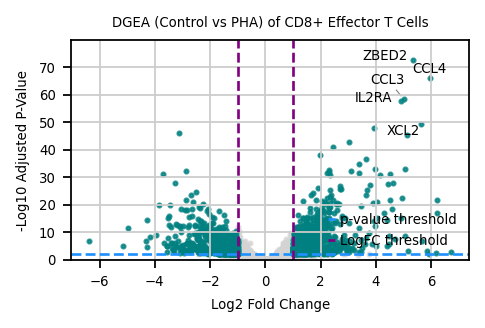

In [257]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()

# Plot labels
plot_title = "DGEA (Control vs PHA) of CD8+ Effector T Cells"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(3, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(row["LogFC"], row["-Log10P"], row["Gene"],
                 fontsize=6, ha="right", va="bottom", color="black")
    )

# Nudge labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="lower right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.1 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()


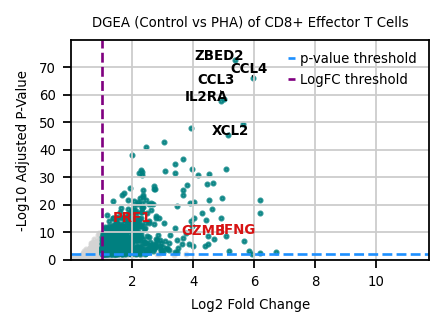

In [271]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()
df = df[df.log2FoldChange>0]
# Plot labels
plot_title = "DGEA (Control vs PHA) of CD8+ Effector T Cells"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(2.75, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

# --- Force-annotate specific genes (add yours here) --------------------------
genes_to_annotate = ["IFNG", "GZMB", "PRF1"]  # <-- edit this list

# Keep any of those genes that are present in df (even if not significant)
force_df = (
    df.loc[df["Gene"].isin(genes_to_annotate), ["Gene", "LogFC", "-Log10P"]]
      .drop_duplicates(subset=["Gene"])
)

# Combine with the top_n significant picks; avoid duplicate labels
labels_df = (
    pd.concat([top_genes[["Gene", "LogFC", "-Log10P"]], force_df], ignore_index=True)
      .drop_duplicates(subset=["Gene"])
)

# If you want forced labels to stand out (e.g., darker text), make a set:
forced_set = set(force_df["Gene"])

texts = []
for _, row in labels_df.iterrows():
    is_forced = row["Gene"] in forced_set
    texts.append(
        plt.text(
            row["LogFC"], row["-Log10P"], row["Gene"],
            fontsize=6,
            ha="right", va="bottom",
            color="#D71313" if is_forced else "black",   # forced a bit bolder
            fontweight="bold"
        )
    )

# Nudge labels to avoid overlap (keeps arrows for all labels)
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
)

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="upper right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.75 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.savefig('Figures/Drug_DGE/DESeq2_PHA_CD8_volcano.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [228]:
import numpy as np
import pandas as pd

# --- Inputs: DESeq2/PyDESeq2 shrunk results ---
# res_shr_df must have: 'gene', 'log2FoldChange', 'padj'
df = res_shr.copy()

# Thresholds (same as your volcano)
fc_threshold   = 1.0
pval_threshold = 0.01

# Clean + prepare
df = df.rename(columns={'gene':'Gene', 'log2FoldChange':'LogFC', 'padj':'Adjusted_PValue'})
df['LogFC'] = pd.to_numeric(df['LogFC'], errors='coerce')
df['Adjusted_PValue'] = pd.to_numeric(df['Adjusted_PValue'], errors='coerce')
df = df.dropna(subset=['LogFC','Adjusted_PValue'])

# For sorting by significance like your volcano (-log10 padj)
df['-Log10P'] = -np.log10(df['Adjusted_PValue'].clip(lower=1e-300))

# Regulation labels
df['Regulation'] = np.where(
    df['LogFC'] >  fc_threshold, 'Upregulated',
    np.where(df['LogFC'] < -fc_threshold, 'Downregulated', 'Non-significant')
)

# Significant mask (|LFC| & padj)
significant = (df['Adjusted_PValue'] < pval_threshold) & (df['LogFC'].abs() > fc_threshold)

# Sort: most significant first, then by effect size
significant_genes_df = (
    df.loc[significant]
      .assign(absLFC=lambda x: x['LogFC'].abs())
      .sort_values(by=['-Log10P','absLFC'], ascending=[False, False])
      .drop(columns=['absLFC'])
)

# Save
# filename = 'Final_Notebooks/Figures/Drug_DGE/significant_genes_Control_vs_PHA_CD8.csv'
# cols_out = ['Gene','LogFC','Adjusted_PValue','Regulation']
# significant_genes_df[cols_out].to_csv(filename, index=False)

# print(f"Saved {significant_genes_df.shape[0]} significant genes -> {filename}")


In [260]:
significant_genes_df[significant_genes_df.Gene=='GZMB']

,baseMean,LogFC,lfcSE,stat,pvalue,Adjusted_PValue,Gene,-Log10P,Regulation
GZMB,10567.848423,3.565087,0.262956,13.851604,1.244027e-43,2.081879e-40,GZMB,39.681544,Upregulated


In [229]:
Up_genes = significant_genes_df[significant_genes_df.Regulation=='Upregulated'].Gene
Down_genes = significant_genes_df[significant_genes_df.Regulation=='Downregulated'].Gene

In [230]:
# Print the results
print(f"Number of upregulated genes: {len(Up_genes)}")
print(f"Number of downregulated genes: {len(Down_genes)}")

Number of upregulated genes: 962
Number of downregulated genes: 828


In [231]:
# Enricr API
enr_up = gp.enrichr(Up_genes,
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_up.res2d = enr_up.res2d[enr_up.res2d["Adjusted P-value"]<0.05]

enr_up.res2d = enr_up.res2d[enr_up.res2d['Term'].str.contains(r'_TOLERANCE_|REGULATION_OF_T_CELL|CYTOTOX', na=False)]

enr_up.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1409,c5.all.v2023.2.Hs.symbols.gmt,LEUKOCYTE_MEDIATED_CYTOTOXICITY,20/139,0.000005,0.000202,3.639559,44.254305,GZMB;CD160;TAP2;PRF1;PRDX1;CEBPG;TUBB;KLRD1;LA...
2306,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_T_CELL_MEDIATED_IMMUNITY,6/29,0.001723,0.022948,5.805383,36.944752,SLAMF1;FOXP3;IL4I1;XCL1;AHR;KLRD1
2307,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_T_CELL_PROLIFERATION,14/72,0.000004,0.000158,5.239911,65.210280,CD274;FOXP3;HAVCR2;PTPN6;PELI1;CTLA4;IL4I1;LGA...
3239,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_MEDIATED_IMMUNITY,9/69,0.004039,0.044108,3.300371,18.190712,SLAMF1;FOXP3;TAP2;IL23R;ARID5A;XCL1;P2RX7;RSAD...
3241,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_PROLIFERATION,14/105,0.000299,0.006333,3.344141,27.133560,SLAMF1;CD274;HAVCR2;CD70;PNP;CD40LG;IL23R;FOXP...


In [232]:
enr_dw = gp.enrichr(Down_genes,
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"]<0.05]

enr_dw.res2d = enr_dw.res2d[enr_dw.res2d['Term'].str.contains(r'_TOLERANCE_|REGULATION_OF_T_CELL|CYTOTOX', na=False)]
enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes


In [233]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(20), enr_dw.res2d.head()])

/tmp/ipykernel_981355/4166764634.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


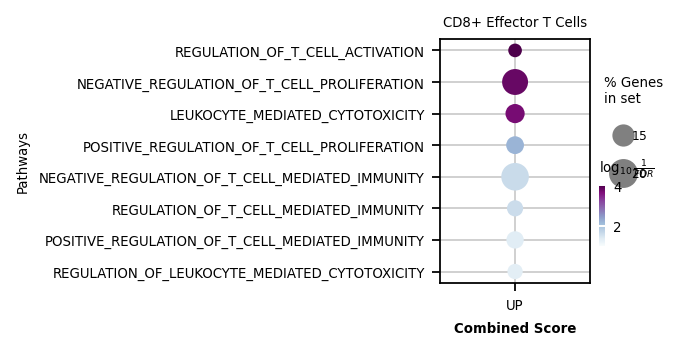

In [237]:
# display multi-dataset
ax = gp.dotplot(enr_res,figsize=(1.5,2),
                x='UP_DW',
                x_order = ["UP","DOWN"],
                title="",
                cmap = 'BuPu',
                size=10,
                show_ring=False,vmin=0)

ax.set_title("CD8+ Effector T Cells", fontsize=6)

ax.set_xlabel("Combined Score", fontsize=6)  
ax.set_ylabel("Pathways", fontsize=6)    

ax.tick_params(axis='both', which='major', labelsize=6)
plt.tight_layout()

plt.savefig('Figures/Drug_DGE/GSEA_DESeq2_PHA_CD8.pdf', bbox_inches='tight',dpi=300)
plt.show()

## Cytotoxicity in PHA vs Control in NK Cells

In [21]:
bdata = adata_new[adata_new.obs.Broad_Manual_Anno_renamed.isin(["NK Cells"])].copy()
bdata = bdata[bdata.obs.Condition.isin(["Control","PHA"])].copy()
bdata

AnnData object with n_obs × n_vars = 4638 × 16537
    obs: 'ExperimentID', 'ConditionID', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'Donor', 'Condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'predicted_doublet_0.2', 'predicted_doublet_0.25', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'Annotations_broad', 'Broad_Manual_Anno', 'Broad_Manual_Anno_renamed'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'h

In [22]:
bdata.layers['counts'] = bdata.raw.X

In [23]:
# --- CONFIG (edit these) ------------------------------------------------------
CONDITION_COLUMN = "Condition"        # bdata.obs column with conditions
SAMPLE_COLUMN    = "sample"           # bdata.obs column with sample IDs
BLOCK_COLUMN     = None               # e.g., "Donor" if you want paired design; else None

# Contrast: results will be (B vs A)
CONDITION_A = "Control"       # reference / denominator
CONDITION_B = "PHA"  # numerator

# Filtering: keep genes with >= MIN_COUNT in at least MIN_SAMPLES pseudobulks
MIN_COUNT   = 10
MIN_SAMPLES = 2

# Output files (set to None to skip writing)
OUT_RAW_CSV   = "Final_Objects/DESeq_psudobulk/PHA_NK_deseq2_results_raw.csv"
OUT_SHR_CSV   = "Final_Objects/DESeq_psudobulk/PHA_NK_deseq2_results_shrunk.csv"

# ----------------------------

import scipy.sparse as sp
import decoupler as dc

# 1) Build pseudobulk (sum UMI counts per gene within each sample)
# Prefer counts layer if present:
layer_name = "counts" if "counts" in bdata.layers else None

pb = dc.get_pseudobulk(
    bdata,
    sample_col=SAMPLE_COLUMN,
    groups_col=[CONDITION_COLUMN],   # keeps Condition in pb.obs
    layer=layer_name,                # None => uses .X
    mode="sum",
    min_cells=0,
    min_counts=0,
)

# Ensure integer counts (PyDESeq2 expects integers)
if sp.issparse(pb.X):
    pb.X = pb.X.A
pb.X = np.asarray(np.rint(pb.X), dtype=np.int64)

# 2) Basic gene filtering (fast, bulk-style)
# Keep genes with >= MIN_COUNT in >= MIN_SAMPLES samples overall
keep = (pb.X >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
pb = pb[:, np.where(keep)[0]].copy()

# 3) Make sure we have exactly two condition levels and >=2 reps per level
conds = pb.obs[CONDITION_COLUMN].astype(str)
levels = pd.Index(sorted(conds.unique()))
if len(levels) != 2:
    raise ValueError(f"Expected exactly 2 condition levels in '{CONDITION_COLUMN}', found {list(levels)}.")
counts_per_level = conds.value_counts()
if (counts_per_level < 2).any():
    raise ValueError(f"Each condition needs >=2 replicates for DESeq2 pseudobulk. Got:\n{counts_per_level}")

REF = CONDITION_A         # reference level (denominator)
TEST = CONDITION_B    # tested level (numerator)

# 4) (Optional) Include a blocking factor if you have one (e.g., Donor)
design_factors = [CONDITION_COLUMN]
if BLOCK_COLUMN is not None:
    if BLOCK_COLUMN not in pb.obs.columns:
        raise ValueError(f"Missing '{BLOCK_COLUMN}' in pb.obs")
    design_factors = [BLOCK_COLUMN, CONDITION_COLUMN]

# 5) Run DE with PyDESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    adata=pb,                         # uses pb.X as counts, pb.obs as metadata
    design_factors=design_factors,    # e.g., ["Condition"] or ["Donor","Condition"]
    ref_level=[CONDITION_COLUMN, REF],
    refit_cooks=True,
    inference=inference,
)

# Fit (size factors, dispersions, GLMs)
dds.deseq2()

# Results for TEST vs REF
stat_res = DeseqStats(
    dds,
    contrast=[CONDITION_COLUMN, TEST, REF],
    inference=inference,
)
stat_res.summary()  # computes Wald stats (log2FC, pvalue, padj)

# 1) RAW (pre-shrink) results
res_raw = stat_res.results_df.copy()

# 2) LFC shrinkage; this updates stat_res.results_df IN PLACE
coeff_name = stat_res.LFC.columns[stat_res.contrast_idx]
stat_res.lfc_shrink(coeff=coeff_name)

# 3) SHRUNK results (now 'log2FoldChange' is the shrunken one)
res_shr = stat_res.results_df.copy()

# Optional: enforce numeric dtypes (robust against odd casting)
for col in ["log2FoldChange", "padj", "pvalue", "baseMean"]:
    if col in res_shr.columns:
        res_shr[col] = pd.to_numeric(res_shr[col], errors="coerce")
    if col in res_raw.columns:
        res_raw[col] = pd.to_numeric(res_raw[col], errors="coerce")

# Save (optional)
if OUT_RAW_CSV:
    res_raw.to_csv(OUT_RAW_CSV, index=False)
if OUT_SHR_CSV:
    res_shr.to_csv(OUT_SHR_CSV, index=False)

# Sanity check
print("Top DE genes (shrunken LFC):")
print(res_shr.sort_values("padj").head(10))



Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.63 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 1.70 seconds.

Fitting LFCs...
... done in 1.71 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.78 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: Condition PHA vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      21.175860        0.103519  0.555490  0.186356  0.852165  0.915535
A1BG-AS1   5.610805       -0.384600  0.638555 -0.602297  0.546977  0.701788
A2M-AS1    9.753864       -2.512611  1.437014 -1.748494  0.080378  0.184813
AAAS      18.902773       -0.049748  0.352975 -0.140940  0.887918  0.937693
AACS      15.676573        1.401342  0.408124  3.433616  0.000596  0.003553
...             ...             ...       ...       ...       ...       ...
ZWINT      4.599820        1.936010  0.885766  2.185689  0.028838  0.083643
ZXDC      26.065365        0.254058  0.338488  0.750568  0.452913  0.622456
ZYG11B    16.052949       -0.763075  0.446441 -1.709240  0.087407  0.196687
ZYX       85.727471        0.028985  0.228643  0.126767  0.899124  0.944956
ZZEF1     48.399620       -0.348474  0.276157 -1.261870  0.206996  0.364895

[10045 rows x 6 columns]

... done in 1.97 seconds.



Shrunk log2 fold change & Wald test p-value: Condition PHA vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      21.175860        0.048364  0.443461  0.186356  0.852165  0.915535
A1BG-AS1   5.610805       -0.153968  0.489225 -0.602297  0.546977  0.701788
A2M-AS1    9.753864       -0.282748  0.662158 -1.748494  0.080378  0.184813
AAAS      18.902773       -0.033391  0.317722 -0.140940  0.887918  0.937693
AACS      15.676573        1.202039  0.408584  3.433616  0.000596  0.003553
...             ...             ...       ...       ...       ...       ...
ZWINT      4.599820        0.924190  0.897805  2.185689  0.028838  0.083643
ZXDC      26.065365        0.179346  0.313994  0.750568  0.452913  0.622456
ZYG11B    16.052949       -0.505795  0.424655 -1.709240  0.087407  0.196687
ZYX       85.727471        0.024454  0.218527  0.126767  0.899124  0.944956
ZZEF1     48.399620       -0.277420  0.263493 -1.261870  0.206996  0.364895

[10045 rows x 6 c

In [275]:
res_shr['gene'] = res_shr.index

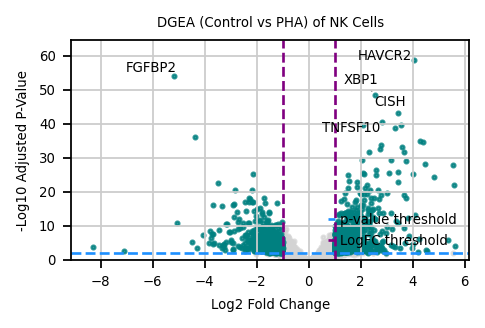

In [276]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()

# Plot labels
plot_title = "DGEA (Control vs PHA) of NK Cells"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(3, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

texts = []
for _, row in top_genes.iterrows():
    texts.append(
        plt.text(row["LogFC"], row["-Log10P"], row["Gene"],
                 fontsize=6, ha="right", va="bottom", color="black")
    )

# Nudge labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="lower right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.1 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()


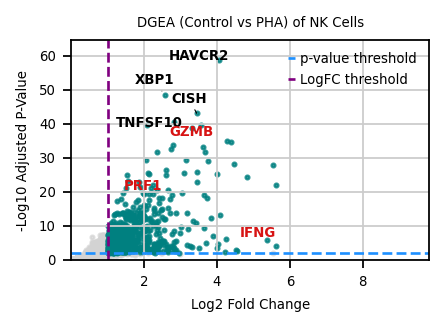

In [278]:
from adjustText import adjust_text

# ------------------------------------------------------------------
df = res_shr.copy()
df = df[df.log2FoldChange>0]
# Plot labels
plot_title = "DGEA (Control vs PHA) of NK Cells"

# Thresholds
fc_threshold = 1         # |log2FC| cutoff
pval_threshold = 0.01      # BH-adjusted p-value cutoff
top_n = 5                  # number of top significant genes to annotate
# ------------------------------------------------------------------

# Safety/clean-up
df = df.rename(columns={"gene":"Gene", "log2FoldChange":"LogFC", "padj":"Adjusted_PValue"})
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["LogFC", "Adjusted_PValue"])

# Replace zero padj with tiny number to avoid -log10(0)
padj_for_plot = df["Adjusted_PValue"].clip(lower=1e-300)
df["-Log10P"] = -np.log10(padj_for_plot)

# Regulation categories for coloring (optional, if you want separate colors)
df["Regulation"] = np.where(
    df["LogFC"] > fc_threshold, "Upregulated",
    np.where(df["LogFC"] < -fc_threshold, "Downregulated", "Non-significant")
)

# Significance mask
sig_mask = (df["Adjusted_PValue"] < pval_threshold) & (np.abs(df["LogFC"]) > fc_threshold)

# Start plotting
plt.figure(figsize=(2.75, 2))

# Non-significant
plt.scatter(df.loc[~sig_mask, "LogFC"], df.loc[~sig_mask, "-Log10P"],
            color="lightgray", alpha=0.7, s=3)

# Significant
plt.scatter(df.loc[sig_mask, "LogFC"], df.loc[sig_mask, "-Log10P"],
            color="teal", alpha=0.8, s=3)

# Top N significant genes to annotate (by -log10P, then |LogFC|)
top_genes = (
    df.loc[sig_mask]
      .assign(absLFC=lambda x: x["LogFC"].abs())
      .sort_values(by=["-Log10P", "absLFC"], ascending=[False, False])
      .head(top_n)
)

# --- Force-annotate specific genes (add yours here) --------------------------
genes_to_annotate = ["IFNG", "GZMB", "PRF1"]  # <-- edit this list

# Keep any of those genes that are present in df (even if not significant)
force_df = (
    df.loc[df["Gene"].isin(genes_to_annotate), ["Gene", "LogFC", "-Log10P"]]
      .drop_duplicates(subset=["Gene"])
)

# Combine with the top_n significant picks; avoid duplicate labels
labels_df = (
    pd.concat([top_genes[["Gene", "LogFC", "-Log10P"]], force_df], ignore_index=True)
      .drop_duplicates(subset=["Gene"])
)

# If you want forced labels to stand out (e.g., darker text), make a set:
forced_set = set(force_df["Gene"])

texts = []
for _, row in labels_df.iterrows():
    is_forced = row["Gene"] in forced_set
    texts.append(
        plt.text(
            row["LogFC"], row["-Log10P"], row["Gene"],
            fontsize=6,
            ha="right", va="bottom",
            color="#D71313" if is_forced else "black",   # forced a bit bolder
            fontweight="bold"
        )
    )

# Nudge labels to avoid overlap (keeps arrows for all labels)
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
)

# Threshold lines
plt.axhline(-np.log10(pval_threshold), color="dodgerblue", linestyle="--", linewidth=1.2, label="p-value threshold")
plt.axvline(fc_threshold, color="purple", linestyle="--", linewidth=1.2, label="LogFC threshold")
plt.axvline(-fc_threshold, color="purple", linestyle="--", linewidth=1.2)

# Aesthetics
plt.xlabel("Log2 Fold Change", fontsize=6)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=6)
plt.title(plot_title, fontsize=6)
plt.legend(loc="upper right", frameon=False, fontsize=6)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

# Nice limits with headroom
x_min = df["LogFC"].min()
x_max = df["LogFC"].max()
y_max = df["-Log10P"].max()
plt.xlim(x_min * (1.1 if x_min < 0 else 0.9), x_max * (1.75 if x_max > 0 else 0.9))
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.savefig('Figures/Drug_DGE/DESeq2_PHA_NK_volcano.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [245]:
import numpy as np
import pandas as pd

# --- Inputs: DESeq2/PyDESeq2 shrunk results ---
# res_shr_df must have: 'gene', 'log2FoldChange', 'padj'
df = res_shr.copy()

# Thresholds (same as your volcano)
fc_threshold   = 1.0
pval_threshold = 0.01

# Clean + prepare
df = df.rename(columns={'gene':'Gene', 'log2FoldChange':'LogFC', 'padj':'Adjusted_PValue'})
df['LogFC'] = pd.to_numeric(df['LogFC'], errors='coerce')
df['Adjusted_PValue'] = pd.to_numeric(df['Adjusted_PValue'], errors='coerce')
df = df.dropna(subset=['LogFC','Adjusted_PValue'])

# For sorting by significance like your volcano (-log10 padj)
df['-Log10P'] = -np.log10(df['Adjusted_PValue'].clip(lower=1e-300))

# Regulation labels
df['Regulation'] = np.where(
    df['LogFC'] >  fc_threshold, 'Upregulated',
    np.where(df['LogFC'] < -fc_threshold, 'Downregulated', 'Non-significant')
)

# Significant mask (|LFC| & padj)
significant = (df['Adjusted_PValue'] < pval_threshold) & (df['LogFC'].abs() > fc_threshold)

# Sort: most significant first, then by effect size
significant_genes_df = (
    df.loc[significant]
      .assign(absLFC=lambda x: x['LogFC'].abs())
      .sort_values(by=['-Log10P','absLFC'], ascending=[False, False])
      .drop(columns=['absLFC'])
)

# Save
# filename = 'Final_Notebooks/Figures/Drug_DGE/significant_genes_Control_vs_PHA_NK.csv'
# cols_out = ['Gene','LogFC','Adjusted_PValue','Regulation']
# significant_genes_df[cols_out].to_csv(filename, index=False)

# print(f"Saved {significant_genes_df.shape[0]} significant genes -> {filename}")


In [246]:
Up_genes = significant_genes_df[significant_genes_df.Regulation=='Upregulated'].Gene
Down_genes = significant_genes_df[significant_genes_df.Regulation=='Downregulated'].Gene

In [247]:
# Print the results
print(f"Number of upregulated genes: {len(Up_genes)}")
print(f"Number of downregulated genes: {len(Down_genes)}")

Number of upregulated genes: 651
Number of downregulated genes: 553


In [248]:
# Enricr API
enr_up = gp.enrichr(Up_genes,
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_up.res2d = enr_up.res2d[enr_up.res2d["Adjusted P-value"]<0.05]

enr_up.res2d = enr_up.res2d[enr_up.res2d['Term'].str.contains(r'_TOLERANCE_|REGULATION_OF_T_CELL|CYTOTOX', na=False)]

enr_up.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1196,c5.all.v2023.2.Hs.symbols.gmt,LEUKOCYTE_MEDIATED_CYTOTOXICITY,19/139,5.621541e-08,0.000004,5.210788,86.989292,CTSC;GZMB;SLAMF7;TAP2;PRF1;TUBB;KLRC1;NCR3;LAG...
1988,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_T_CELL_PROLIFERATION,8/72,1.653916e-03,0.019229,4.177197,26.753319,CD274;HAVCR2;PTPN6;LGALS9;XCL1;CEBPB;PRNP;IL2RA
2822,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_CYTOKINE_PRODUCTION,5/26,1.056656e-03,0.013536,8.086337,55.412807,XCL1;IL18R1;RSAD2;TRAF2;CD55
2826,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_MEDIATED_IMMUNITY,7/69,5.308137e-03,0.046522,3.797712,19.894371,TAP2;XCL1;IL18R1;RSAD2;HSPD1;TRAF2;CD55
2829,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_T_CELL_RECEPTOR_SIGNALI...,4/17,1.550433e-03,0.018257,10.523570,68.079302,CCR7;CD226;RAB29;TESPA1


In [249]:
enr_dw = gp.enrichr(Down_genes,
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"]<0.05]

enr_dw.res2d = enr_dw.res2d[enr_dw.res2d['Term'].str.contains(r'_TOLERANCE_|REGULATION_OF_T_CELL|CYTOTOX', na=False)]

enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes


In [250]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(20), enr_dw.res2d.head()])

/tmp/ipykernel_981355/2528055067.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


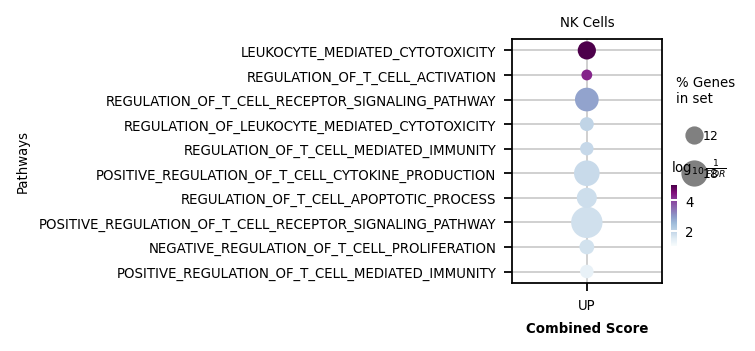

In [252]:
# display multi-dataset
ax = gp.dotplot(enr_res,figsize=(1.5,2),
                x='UP_DW',
                x_order = ["UP","DOWN"],
                title="GO_BP",
                cmap = 'BuPu',
                size=10,
                show_ring=False,vmin=0)

ax.set_title("NK Cells", fontsize=6)

ax.set_xlabel("Combined Score", fontsize=6)  
ax.set_ylabel("Pathways", fontsize=6)    

ax.tick_params(axis='both', which='major', labelsize=6)
plt.tight_layout()
plt.savefig('Figures/Drug_DGE/GSEA_DESeq2_PHA_NK.pdf', bbox_inches='tight',dpi=300)
plt.show()

## Perform GO term analysis on DGE by celltype analysis of unstimulated drug vs control

### For BTP2 ###

In [182]:
# Generate file in the Drug comparison Notebook
filename = f"Figures/Drug_comparison_DESeq2/BTP2_vs_Control/DESeq2_significant_BTP2_vs_Control.csv"
significant_genes = pd.read_csv(filename)

degs_up = significant_genes[significant_genes['Regulation']=='upregulated']
degs_dw = significant_genes[significant_genes['Regulation']=='downregulated']

# Enricr API
enr_up = gp.enrichr(degs_up["names"].to_list(),
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_up.res2d = enr_up.res2d[enr_up.res2d["Adjusted P-value"]<0.05]

enr_up.res2d = enr_up.res2d[enr_up.res2d['Term'].str.contains(r'TOLERANCE_|CYTOTOX|REGULAT', na=False)]


enr_up.res2d = enr_up.res2d.sort_values(by='Adjusted P-value', ascending=True)
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes


In [183]:
enr_dw = gp.enrichr(degs_dw["names"].to_list(),
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"]<0.05]

enr_dw.res2d = enr_dw.res2d[enr_dw.res2d['Term'].str.contains(r'_TOLERANCE_|REGULAT|CYTOTOX', na=False)]

enr_dw.res2d = enr_dw.res2d.sort_values(by='Adjusted P-value', ascending=True)
enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
151,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_B_CELL_DIFFERENTIATION,1/6,0.002155,0.04983,816.734266,5014.822024,INHBA
152,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_CELL_ACTIVATION,2/223,0.002639,0.04983,39.502360,234.543541,INHBA;IL2RA
167,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_GONADOTROPIN_SECRETION,1/7,0.002513,0.04983,691.047337,4136.673980,INHBA
175,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_LYMPHOCYTE_ACTIVATION,2/169,0.001527,0.04983,52.383989,339.666646,INHBA;IL2RA
177,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_MACROPHAGE_DIFFERENTIATION,1/8,0.002872,0.04983,598.876923,3505.056639,INHBA


In [184]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(10), enr_dw.res2d.head(10)])

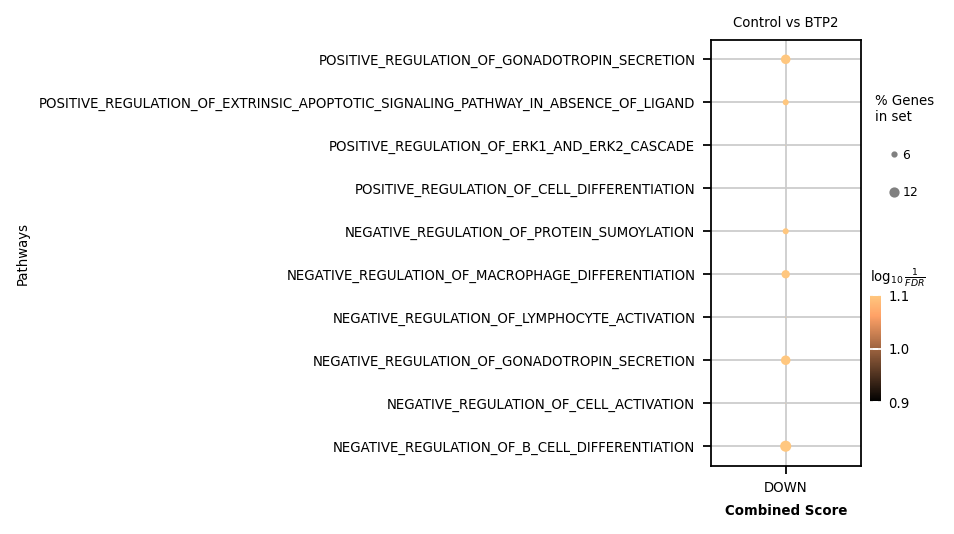

In [185]:
# display multi-dataset
ax = gp.dotplot(enr_res,figsize=(1.5,3.5),
                x='UP_DW',
                x_order = ["UP","DOWN"],
                title="GO_BP",
                cmap = 'copper',
                size=5,cutoff=0.05,
                show_ring=False,vmin=0)

ax.set_title("Control vs BTP2", fontsize=6)

ax.set_xlabel("Combined Score", fontsize=6)  
ax.set_ylabel("Pathways", fontsize=6)    

ax.tick_params(axis='both', which='major', labelsize=6)

#plt.savefig('Final_Notebooks/Figures/Drug_DGE/BTP2_dot_plot_comb.pdf', bbox_inches='tight',dpi=300)
plt.show()

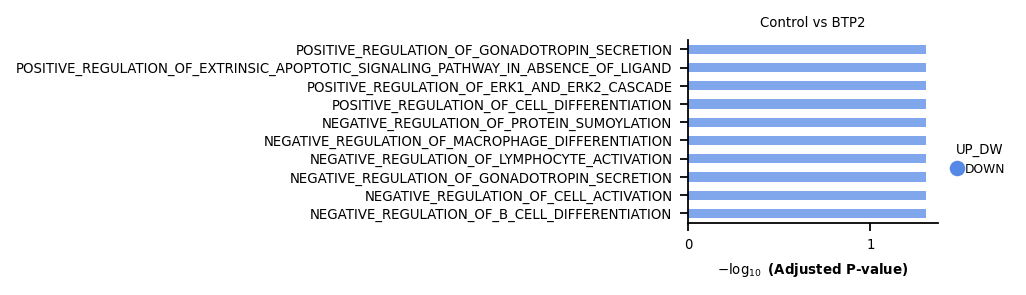

In [186]:
ax = gp.barplot(enr_res, figsize=(2, 1.5), group='UP_DW', title="GO_BP", color=['#5688E6', '#E6695C'])
ax.set_title("Control vs BTP2", fontsize=6)               
ax.set_xlabel(ax.get_xlabel(), fontsize=6)      
ax.set_ylabel(ax.get_ylabel(), fontsize=6)     

ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)
ax.grid(visible=False)

plt.savefig('Figures/Drug_comparison_DESeq2/BTP2_vs_Control/BTP2_bar_plot_comb_DESeq2.pdf', bbox_inches='tight',dpi=300)
plt.show()

### For CM4620 ###

In [177]:
# Generate file in the Drug comparison Notebook
filename = f"Figures/Drug_comparison_DESeq2/CM4620_vs_Control/DESeq2_significant_CM4620_vs_Control.csv"
significant_genes = pd.read_csv(filename)

degs_up = significant_genes[significant_genes['Regulation']=='upregulated']
degs_dw = significant_genes[significant_genes['Regulation']=='downregulated']

# Enricr API
enr_up = gp.enrichr(degs_up["names"].to_list(),
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_up.res2d['Term'] = enr_up.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_up.res2d = enr_up.res2d[enr_up.res2d["Adjusted P-value"]<0.05]

enr_up.res2d = enr_up.res2d[enr_up.res2d['Term'].str.contains(r'_TOLERANCE_|CYTOTOX|REGULAT', na=False)]


enr_up.res2d = enr_up.res2d.sort_values(by='Adjusted P-value', ascending=True)
enr_up.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
102,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_VIRAL_GENOME_REPLICATION,2/55,0.000163,0.016997,164.974511,1438.934807,OAS2;EIF2AK2
221,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_VIRAL_GENOME_REPLICATION,2/85,0.000390,0.021823,105.538922,828.496865,OAS2;EIF2AK2
103,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_VIRAL_PROCESS,2/93,0.000466,0.022850,96.271734,738.462547,OAS2;EIF2AK2
223,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_VIRAL_PROCESS,2/168,0.001510,0.044785,52.701338,342.342746,OAS2;EIF2AK2
211,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_RIBONUCLEASE_ACTIVITY,1/9,0.003231,0.046904,528.393665,3030.383715,OAS2


In [178]:
enr_dw = gp.enrichr(degs_dw["names"].to_list(),
                    gene_sets="GSEA_files/c5.all.v2023.2.Hs.symbols.gmt",
                    organism='human',
                    outdir=None)

enr_dw.res2d['Term'] = enr_dw.res2d['Term'].apply(lambda x: '_'.join(x.split('_')[1:]) if len(x.split('_')) > 1 else None)


enr_dw.res2d = enr_dw.res2d[enr_dw.res2d["Adjusted P-value"]<0.05]

enr_dw.res2d = enr_dw.res2d[enr_dw.res2d['Term'].str.contains(r'_TOLERANCE_|REGULAT|CYTOTOX', na=False)]

enr_dw.res2d = enr_dw.res2d.sort_values(by='Adjusted P-value', ascending=True)
enr_dw.res2d.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
289,c5.all.v2023.2.Hs.symbols.gmt,NEGATIVE_REGULATION_OF_CELL_POPULATION_PROLIFE...,7/957,8.946697e-07,0.000620,22.475418,313.010902,INHBA;IL24;SPP1;CD109;IL2RA;RGCC;CYP1B1
597,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_MULTICELLULAR_ORGANISMAL_DEVELOP...,8/1484,1.014061e-06,0.000620,18.828587,259.863637,INHBA;MAFF;SPP1;CD109;GPR68;IL2RA;RGCC;CYP1B1
535,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_CELL_DIFFERENTIATION,8/1628,2.057101e-06,0.000814,17.018120,222.838889,INHBA;MAFF;TNFSF14;SPP1;CD109;GPR68;IL2RA;RGCC
448,c5.all.v2023.2.Hs.symbols.gmt,POSITIVE_REGULATION_OF_MULTICELLULAR_ORGANISMA...,8/1684,2.660902e-06,0.000814,16.398042,210.499137,INHBA;TNFSF14;CLEC5A;SPP1;GPR68;IL2RA;RGCC;CYP1B1
569,c5.all.v2023.2.Hs.symbols.gmt,REGULATION_OF_HORMONE_LEVELS,5/540,1.721080e-05,0.002339,22.873016,250.916373,INHBA;TIPARP;SPP1;GPR68;CYP1B1


In [179]:
# concat results
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(10), enr_dw.res2d.head(10)])

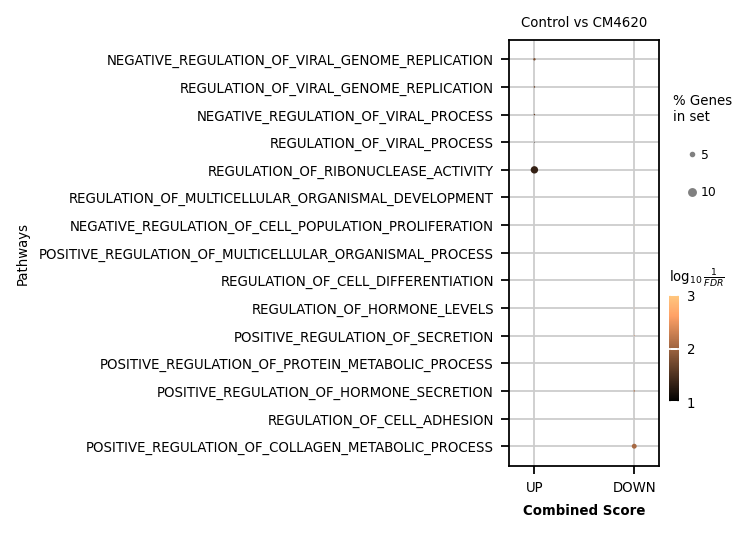

In [180]:
# display multi-dataset
ax = gp.dotplot(enr_res,figsize=(1.5,3.5),
                x='UP_DW',
                x_order = ["UP","DOWN"],
                title="GO_BP",
                cmap = 'copper',
                size=5,cutoff=0.05,
                show_ring=False,vmin=0)

ax.set_title("Control vs CM4620", fontsize=6)

ax.set_xlabel("Combined Score", fontsize=6)  
ax.set_ylabel("Pathways", fontsize=6)    

ax.tick_params(axis='both', which='major', labelsize=6)

#plt.savefig('Final_Notebooks/Figures/Drug_DGE/CM4620_dot_plot_comb.pdf', bbox_inches='tight',dpi=300)
plt.show()

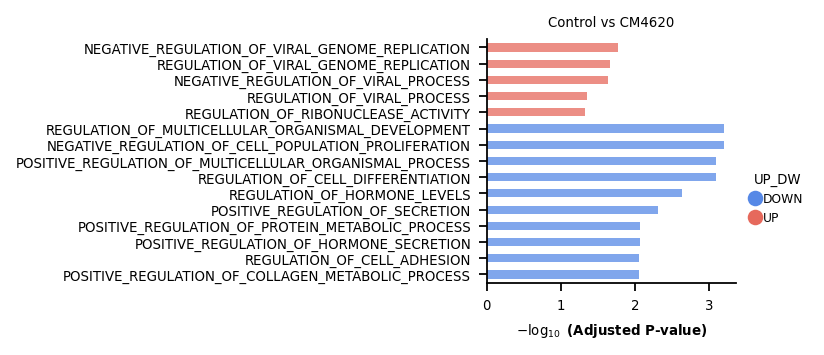

In [181]:
ax = gp.barplot(enr_res, figsize=(2, 2), group='UP_DW', title="GO_BP", color=['#5688E6', '#E6695C'])
ax.set_title("Control vs CM4620", fontsize=6)               
ax.set_xlabel(ax.get_xlabel(), fontsize=6)      
ax.set_ylabel(ax.get_ylabel(), fontsize=6)     

ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)
ax.grid(visible=False)

plt.savefig('Figures/Drug_comparison_DESeq2/CM4620_vs_Control/CM4620_bar_plot_comb_DESeq2.pdf', bbox_inches='tight',dpi=300)
plt.show()

In [171]:
!pip list

Package                   Version
------------------------- --------------
adjustText                1.3.0
anndata                   0.10.9
anyio                     4.6.2.post1
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
array_api_compat          1.9.1
arrow                     1.3.0
asttokens                 2.4.1
async-lru                 2.0.4
attrs                     24.2.0
babel                     2.16.0
beautifulsoup4            4.12.3
bleach                    6.2.0
Brotli                    1.1.0
cached-property           1.5.2
certifi                   2024.8.30
cffi                      1.17.1
charset-normalizer        3.4.0
colorama                  0.4.6
comm                      0.2.2
contourpy                 1.3.0
cycler                    0.12.1
debugpy                   1.8.8
decorator                 5.1.1
decoupler                 1.9.0
defusedxml                0.7.1
entrypoints               0.4
et_xmlfile                2.0.0
exceptiongrou